# KenKen: entrenamiento y detección

Este notebook es una interfaz para vision/model.py. No redefine la CNN ni el preprocesamiento: carga glyph_cnn.pt si existe y entrena automáticamente si no existe.


In [1]:
from pathlib import Path
import sys

HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name == 'vision' else HERE
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_ROOT = PROJECT_ROOT / 'dataset'
MODEL_PATH = PROJECT_ROOT / 'vision' / 'glyph_cnn.pt'
PREDICTION_PATH = PROJECT_ROOT / 'pred.json'
print('Proyecto:', PROJECT_ROOT)
print('Dataset:', DATASET_ROOT)
print('Modelo:', MODEL_PATH)


Proyecto: /home/alexc0dex/Escritorio/UPC/Ciclo_8/Topicos/TB1/Kenken/kenken-cv_project
Dataset: /home/alexc0dex/Escritorio/UPC/Ciclo_8/Topicos/TB1/Kenken/kenken-cv_project/dataset
Modelo: /home/alexc0dex/Escritorio/UPC/Ciclo_8/Topicos/TB1/Kenken/kenken-cv_project/vision/glyph_cnn.pt


In [2]:
from vision.model import (
    DEVICE, evaluate_model, export_json, get_or_train_model, parse_image,
    train_model,
)

print('Dispositivo:', DEVICE)
print('Modelo existente:', MODEL_PATH.exists())


Dispositivo: cpu
Modelo existente: True


## Cargar o entrenar el modelo

La siguiente celda no reentrena si ya existe vision/glyph_cnn.pt. Para forzar un nuevo entrenamiento, elimina ese archivo o ejecuta train_model(...) explícitamente.


In [3]:
EPOCHS = 60
model = get_or_train_model(
    model_path=MODEL_PATH,
    train_root=DATASET_ROOT,
    epochs=EPOCHS,
)
print('Modelo listo:', MODEL_PATH)


Modelo listo: /home/alexc0dex/Escritorio/UPC/Ciclo_8/Topicos/TB1/Kenken/kenken-cv_project/vision/glyph_cnn.pt


## Evaluación reutilizable del modelo

Las métricas se calculan separando tableros completos, para evitar que glyphs de una misma imagen aparezcan en entrenamiento y validación. La matriz de confusión permite revisar especialmente la confusión entre `/` y `+`.


loss: 0.1245
accuracy: 0.9956
balanced_accuracy: 0.9971
top_3_accuracy: 0.9978
macro_precision: 0.9971
macro_recall: 0.9971
macro_f1: 0.9971
weighted_precision: 0.9956
weighted_recall: 0.9956
weighted_f1: 0.9956
mean_confidence: 0.9195
mean_correct_confidence: 0.9195
mean_incorrect_confidence: 0.9202
\nMétricas por clase:
 0 | support= 36 precision=1.000 recall=1.000 f1=1.000
 1 | support=130 precision=0.992 recall=0.992 f1=0.992
 2 | support=108 precision=1.000 recall=1.000 f1=1.000
 3 | support= 68 precision=0.985 recall=0.985 f1=0.985
 4 | support= 60 precision=1.000 recall=1.000 f1=1.000
 5 | support= 37 precision=1.000 recall=1.000 f1=1.000
 6 | support= 36 precision=1.000 recall=1.000 f1=1.000
 7 | support= 14 precision=1.000 recall=1.000 f1=1.000
 8 | support= 31 precision=1.000 recall=1.000 f1=1.000
 9 | support= 17 precision=1.000 recall=1.000 f1=1.000
 + | support= 96 precision=0.990 recall=0.990 f1=0.990
 - | support=139 precision=0.993 recall=0.993 f1=0.993
 * | support= 80

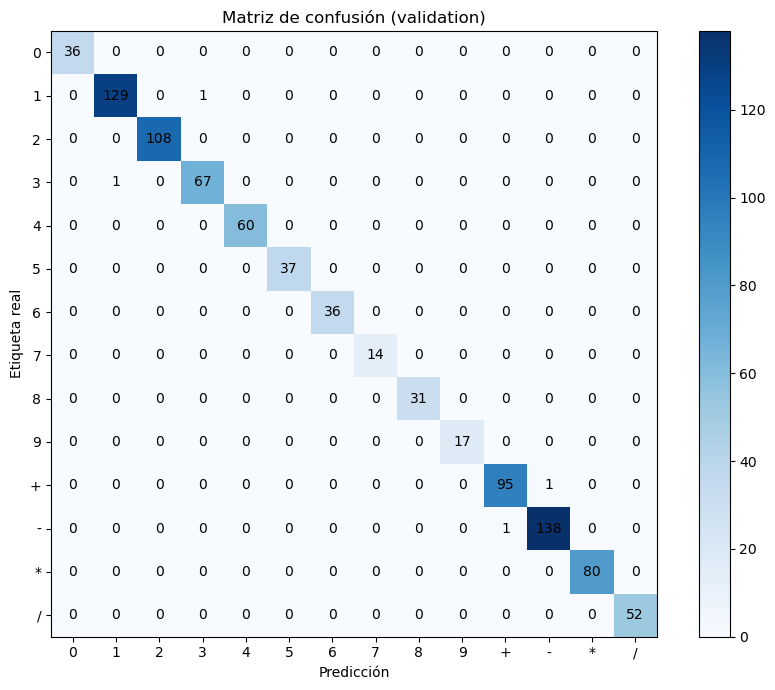

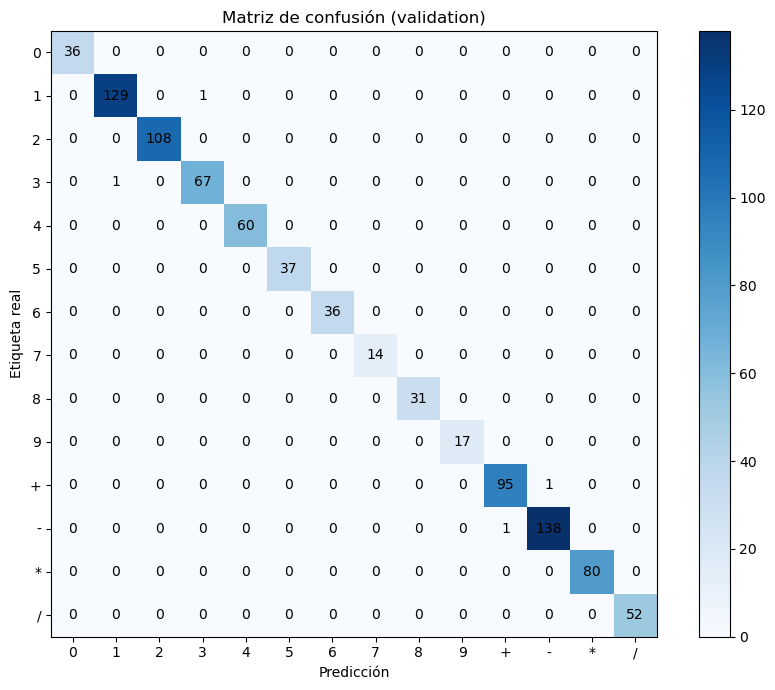

In [4]:
metrics = evaluate_model(
    model,
    DATASET_ROOT,
    validation_fraction=0.2,
    seed=42,
    split='validation',
    plot=True,
)

for key in (
    'loss', 'accuracy', 'balanced_accuracy', 'top_3_accuracy',
    'macro_precision', 'macro_recall', 'macro_f1',
    'weighted_precision', 'weighted_recall', 'weighted_f1',
    'mean_confidence', 'mean_correct_confidence',
    'mean_incorrect_confidence',
):
    print(f'{key}: {metrics[key]:.4f}')

print('\\nMétricas por clase:')
for char, values in metrics['per_class'].items():
    print(
        f"{char:>2} | support={values['support']:>3} "
        f"precision={values['precision']:.3f} "
        f"recall={values['recall']:.3f} "
        f"f1={values['f1']:.3f}"
    )

display(metrics['confusion_figure'])


## Detectar una sola imagen y exportar JSON

Cambia IMAGE_PATH por cualquier imagen KenKen. El JSON contiene el tamaño de la grilla y las jaulas detectadas: op, target y cells.


In [5]:
IMAGE_PATH = DATASET_ROOT / 'images' / '9x9' / 'imagen9x9_1.png'
SINGLE_OUTPUT = PROJECT_ROOT / 'pred_single.json'

if not IMAGE_PATH.exists():
    raise FileNotFoundError(f'No existe la imagen: {IMAGE_PATH}')

board = parse_image(IMAGE_PATH, model)
print('Imagen:', board['filename'])
print('Tamaño detectado:', board['n'])
print('Jaulas detectadas:', len(board['cages']))
print(export_json([str(IMAGE_PATH)], model, SINGLE_OUTPUT))


Imagen: imagen9x9_1.png
Tamaño detectado: 9
Jaulas detectadas: 35
/home/alexc0dex/Escritorio/UPC/Ciclo_8/Topicos/TB1/Kenken/kenken-cv_project/pred_single.json


## Exportar varias imágenes del mismo tamaño

Todas las imágenes de una exportación deben tener el mismo tamaño de grilla.


In [ ]:
SIZE = '9x9'
images = sorted((DATASET_ROOT / 'images' / SIZE).glob('*.png'))
BATCH_OUTPUT = PROJECT_ROOT / ('pred_' + SIZE + '.json')
if not images:
    raise FileNotFoundError('No hay imágenes en ' + str(DATASET_ROOT / 'images' / SIZE))
print(export_json([str(p) for p in images], model, BATCH_OUTPUT))


## Resolver el JSON con CP-SAT

Después de generar pred_single.json, el solver puede consumirlo directamente desde la raíz del proyecto.


In [6]:
from solver import solve_detected_json

solved = solve_detected_json(SINGLE_OUTPUT)
for row in solved['solution']:
    print(' '.join(map(str, row)))


8 3 4 6 7 2 9 5 1
9 8 5 1 6 3 2 7 4
5 6 9 8 3 1 4 2 7
3 2 1 4 8 6 7 9 5
2 7 6 5 9 8 1 4 3
7 1 3 9 2 4 5 8 6
4 9 7 2 1 5 3 6 8
1 4 8 7 5 9 6 3 2
6 5 2 3 4 7 8 1 9


## Uso desde la terminal

Entrenar: python -m vision.model train --dataset dataset --model vision/glyph_cnn.pt --epochs 60

Detectar una imagen: python -m vision.model predict dataset/images/9x9/imagen9x9_1.png --model vision/glyph_cnn.pt --dataset dataset --out pred_single.json

Resolver: python -m solver.solver pred_single.json --filename imagen9x9_1.png
